# BKG Studies

In [21]:
# Running on
# test: Testing dask set up on a few files

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm


In [2]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

Connection method: Direct,
Dashboard: /user/joaquin.siado.castaneda@cern.ch/proxy/8787/status,
Comm: tls://192.168.235.32:8786,Workers: 0
Dashboard: /user/joaquin.siado.castaneda@cern.ch/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
# Settings
numfiles = 3
vr = "test"

sig_2mu = [
    "2Mu2E_100GeV_5p0GeV_0p4mm",
]

sig_4mu = [
    "4Mu_100GeV_5p0GeV_0p4mm",
    # "4Mu_150GeV_5p0GeV_0p27mm",
    # "4Mu_200GeV_5p0GeV_0p2mm",
    # "4Mu_500GeV_5p0GeV_0p08mm",
    # "4Mu_500GeV_5p0GeV_80p0mm",
    # "4Mu_800GeV_5p0GeV_0p05mm",
    # "4Mu_1000GeV_5p0GeV_0p04mm",
]

bkg = [
    # "DYJetsToMuMu_M10to50",
    # "DYJetsToMuMu_M50",
    "TTJets",
    # "QCD_Pt15To20",
    # "QCD_Pt20To30",
    # "QCD_Pt30To50",
    # "QCD_Pt50To80",
    # "QCD_Pt80To120",
    # "QCD_Pt120To170",
    # "QCD_Pt170To300",
    # "QCD_Pt300To470",
    # "QCD_Pt470To600",
    # "QCD_Pt600To800",
    # "QCD_Pt800To1000",
    # "QCD_Pt1000",       
]

#cuts to be applied (slections.yaml)
channels = ["baseNoLj", "bkg_study", "bkg_study_iso",]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]

allsamples = sig_2mu + sig_4mu + bkg
print(allsamples)

figw, figh = 10, 10

# cols = ["b", "r", "g", "c", "k", "y"]
# labels = ["0.15", "0.17", "0.19", "0.21", "0.23", "0.25"]

['2Mu2E_100GeV_5p0GeV_0p4mm', '4Mu_100GeV_5p0GeV_0p4mm', 'TTJets']


In [5]:
runner = processor.Runner(
    # executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)
# channelname="base_ljObjCut_ljIso"
# hist_collections = "displacement_base"
channels = ["baseNoLj", "bkg_study", "bkg_study_iso",]

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
)

fileset = utilities.make_fileset(sig_2mu, "llpNanoAOD_v2", max_files=3, location_cfg="signal_2mu2e_v10.yaml")
output_sig2nal = runner.run(fileset, treename="Events", processor_instance=p)


Output()

Output()

2Mu2E_100GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [7]:
# processor for signal

fileset_sig_4mu = utilities.make_fileset(sig_4mu,  "llpNanoAOD_v2", max_files = numfiles, location_cfg = "signal_4mu_v10.yaml")

runner = processor.Runner(
    # executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
)

#hist collection
p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"], unweighted_hist=True,
)

out_sig4 = runner.run(fileset_sig_4mu, treename="Events", processor_instance=p)
out_sig4 = out_sig4["out"]

Output()

4Mu_100GeV_5p0GeV_0p4mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [8]:
# processor for BKG ...

fileset_bkg    = utilities.make_fileset(bkg, "llpNanoAOD_v2", max_files = numfiles, location_cfg = "backgrounds.yaml",)

runner = processor.Runner(
    # executor=processor.FuturesExecutor(),
    # executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"], unweighted_hist=True,
)

out_bkg = runner.run(fileset_bkg, treename="Events", processor_instance=p)
out_bkg = out_bkg["out"]

Output()

Output()

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


In [10]:
# adding and saving
out_all = output_signal | out_sig4 | out_bkg 
coffea.util.save(out_all, "outputs/bkg_" + vr + ".coffea")

In [11]:
# test
print(out_all.keys())

dict_keys(['out', 'processed', 'exception', '4Mu_100GeV_5p0GeV_0p4mm', 'TTJets'])


In [12]:
# opening file
output = coffea.util.load("outputs/bkg_" + vr + ".coffea")
out = output

In [13]:
# Start plotting

['2Mu2E_100GeV_5p0GeV_0p4mm', '4Mu_100GeV_5p0GeV_0p4mm', 'TTJets']


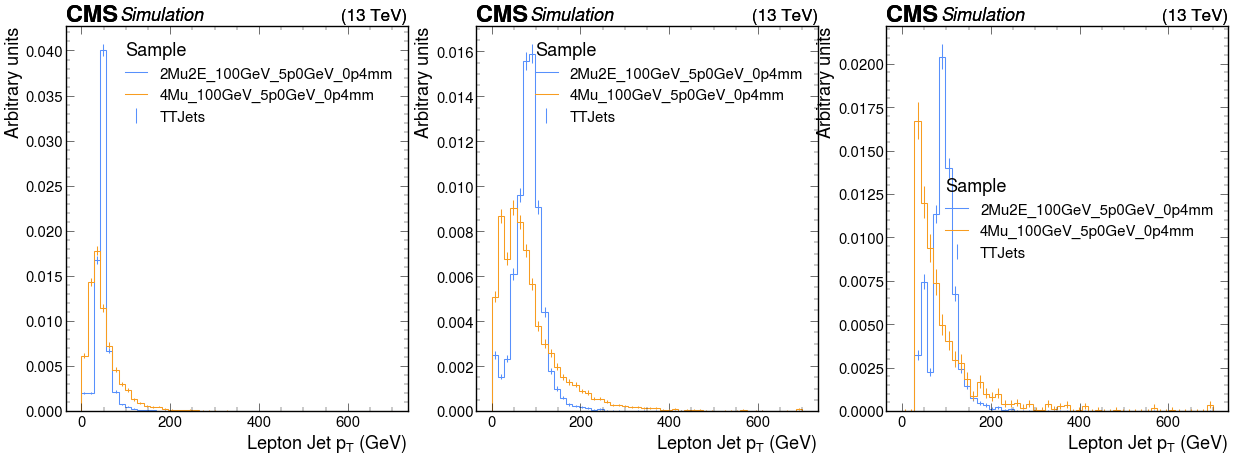

In [20]:
# LJ pt
npl = 3
plt.subplots(1, npl, figsize=(npl*figw, figh))
print(allsamples)
plt.subplot(1, npl, 1)
for sss in allsamples[1:]:
    # print(sss)
    utilities.plot(out[sss]["hists"]["lj_pt"][ch1, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 2)
for sss in allsamples[1:]:
    utilities.plot(out[sss]["hists"]["lj_pt"][ch2, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.subplot(1, npl, 3)
for sss in allsamples[1:]:
    utilities.plot(out[sss]["hists"]["lj_pt"][ch3, ::2j], label = sig_2mu, density=True)
    plt.legend(allsamples, title="Sample", alignment="left", loc=0)
    # plt.title("den")
    plt.ylabel("Arbitrary units")

plt.savefig(f"plots/BKG_{vr}_lj_pt", bbox_inches="tight")

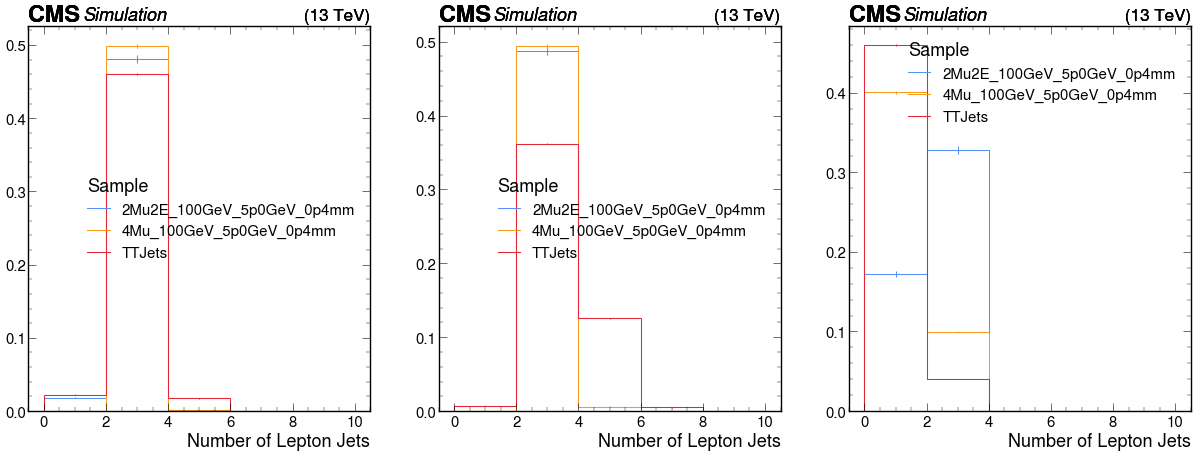

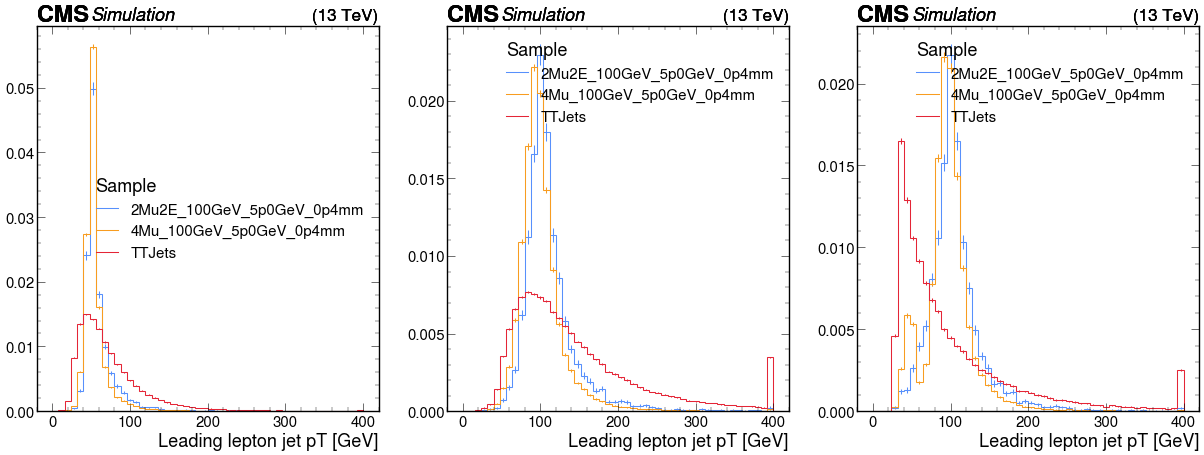

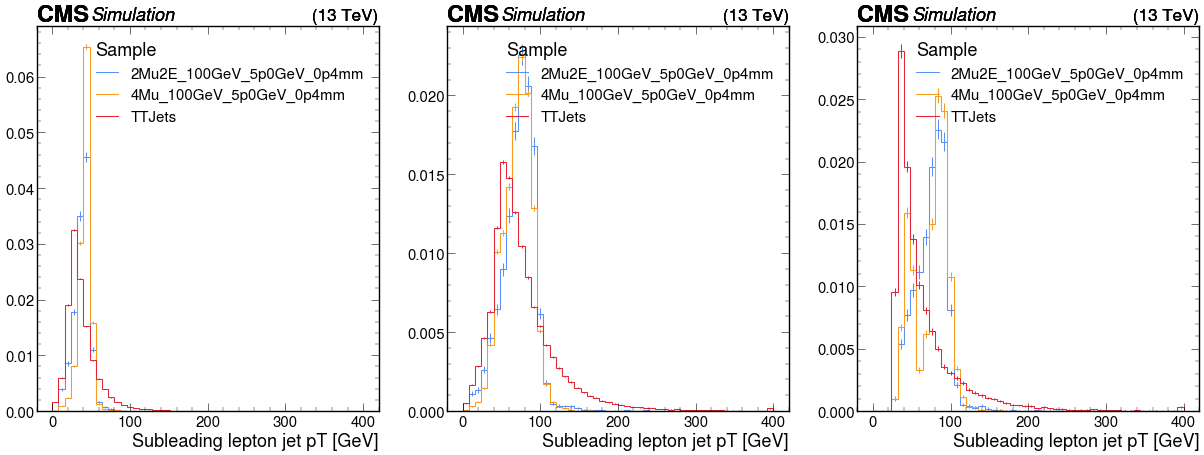

In [16]:
# LJ quantities

# "lj_lj_invmass", "lj_lj_absdphi", "lj_lj_absdR""lj_lj_absdeta"
# , "lj_lj_absdR", "lj_lj_invmass"]
hists_to_plot = ["lj_n","lj0_pt", "lj1_pt"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")

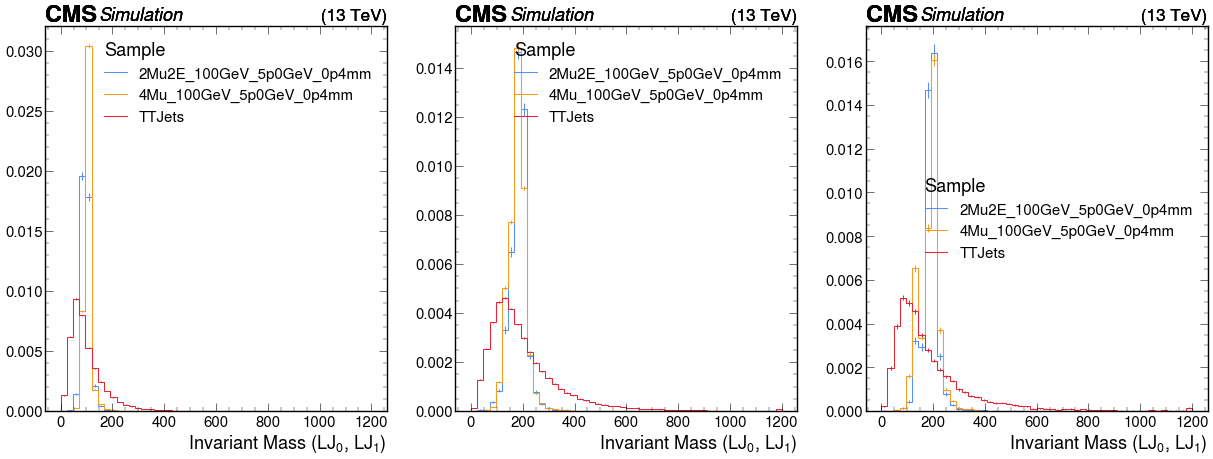

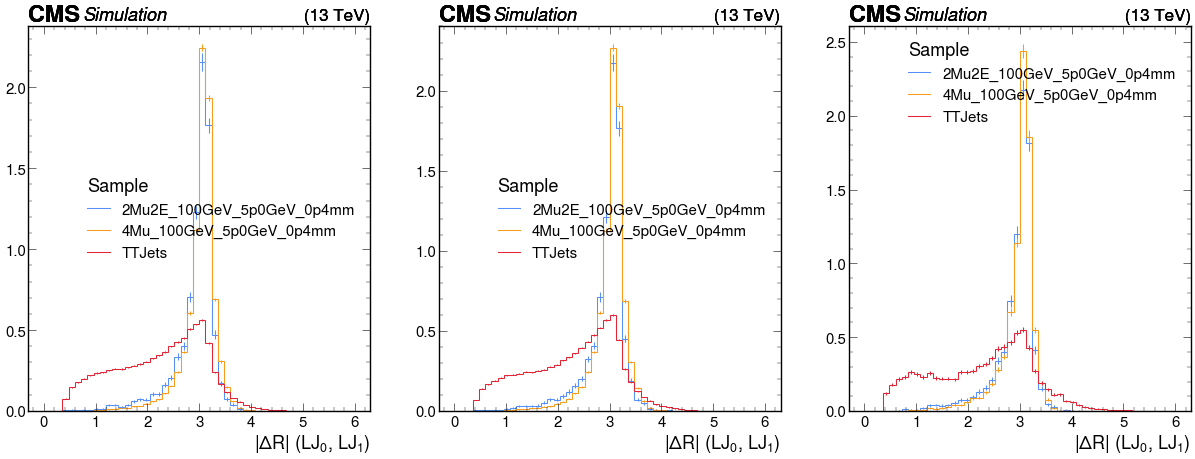

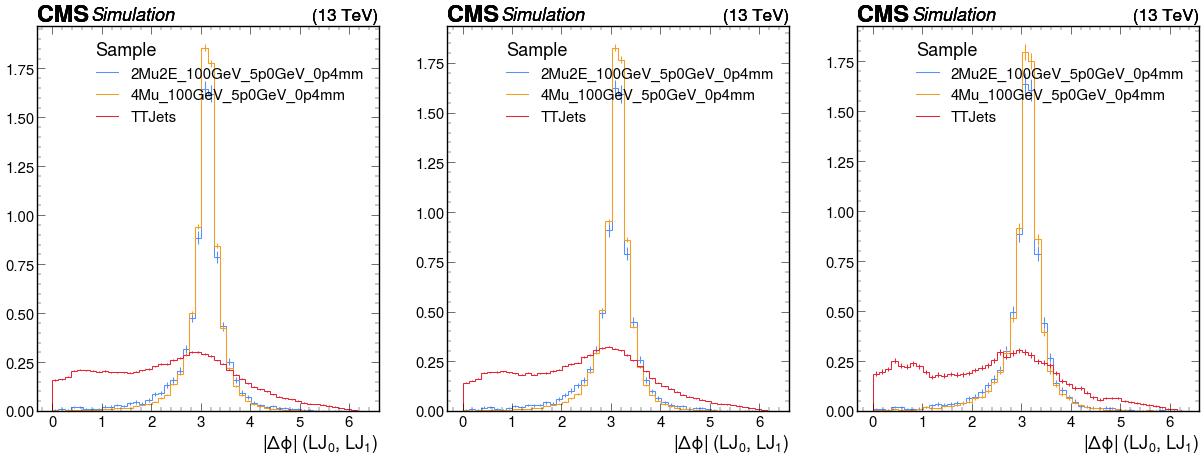

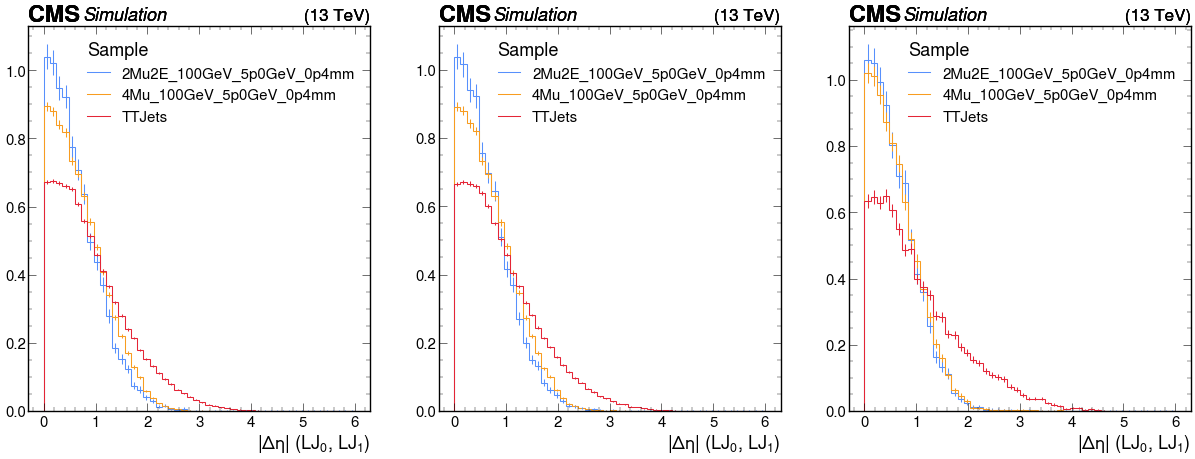

In [17]:
# LJ-LJ quantities

hists_to_plot = ["lj_lj_invmass", "lj_lj_absdR", "lj_lj_absdphi", "lj_lj_absdeta"]

for hst in hists_to_plot:
    npl = 3
    plt.subplots(1, npl, figsize=(npl*figw, figh))
    
    plt.subplot(1, npl, 1)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch1, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 2)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch2, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")
    
    plt.subplot(1, npl, 3)
    for sss in allsamples:
        utilities.plot(out[sss]["hists"][hst][ch3, ::2j], density=True)
        plt.legend(allsamples, title="Sample", alignment="left", loc=0)
        # plt.title("den")